# ARTI403 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain

Images are taken from `skimage.data` (https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html) and saved in the `images/` folder.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage.exposure import match_histograms

os.makedirs('images', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save the skimage images used in this lab so they can be uploaded to GitHub
for name in ['moon', 'rocket', 'chelsea', 'camera']:
    im = getattr(data, name)()
    cv2.imwrite(f'images/{name}.png', cv2.cvtColor(im, cv2.COLOR_RGB2BGR) if im.ndim == 3 else im)
print(sorted(os.listdir('images')))

['camera.png', 'chelsea.png', 'moon.png', 'rocket.png']


## Procedural Steps
### Task 1: Thresholding
**Step 1:** Apply a fixed threshold on an image with several threshold values.

The manual uses `../images/Parrot.png` (not part of skimage). If `images/Parrot.png` exists it is used; otherwise the skimage `camera` image is used instead.

Using: images/camera.png (512, 512)


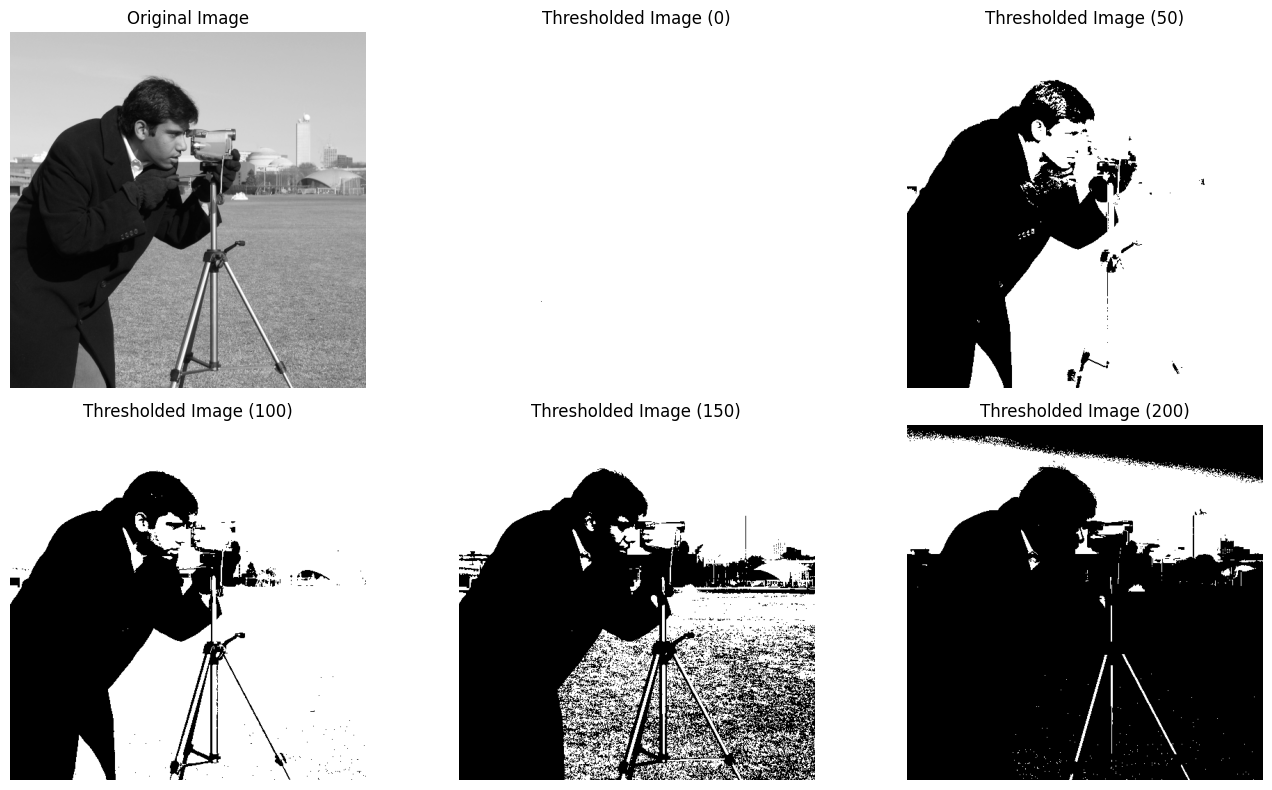

In [2]:
path = 'images/Parrot.png'
if os.path.exists(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
else:
    path = 'images/camera.png'
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
print('Using:', path, img.shape)

threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image'); axes[0].axis('off')
for ax, t in zip(axes[1:], threshold_values):
    ret, thresh = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Thresholded Image ({t})'); ax.axis('off')
plt.tight_layout()
plt.savefig('results/task1_thresholding.png', dpi=120)
plt.show()

### Task 2: Histogram Processing
**Step 1:** Load necessary libraries (done above).

**Step 2:** Load the moon image.

In [3]:
img = data.moon()
print(img.shape, img.dtype, img.min(), img.max())

(512, 512) uint8 0 255


**Step 3:** Contrast stretching – rescale intensities between the 2nd and 98th percentiles.

In [4]:
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print('p2 =', p2, ', p98 =', p98)

p2 = 78.0 , p98 = 129.0


**Step 4:** Display the images with their histograms (Step 2 and Step 3).

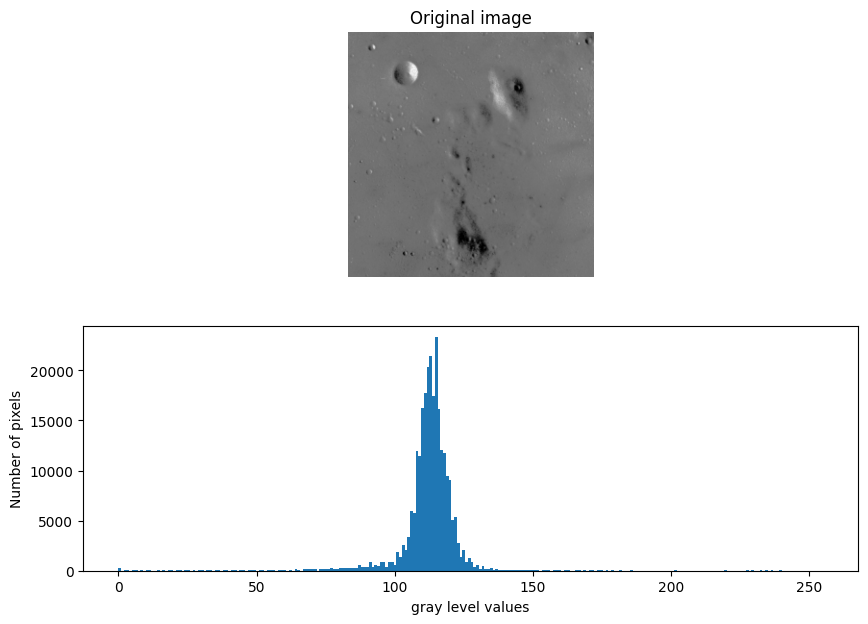

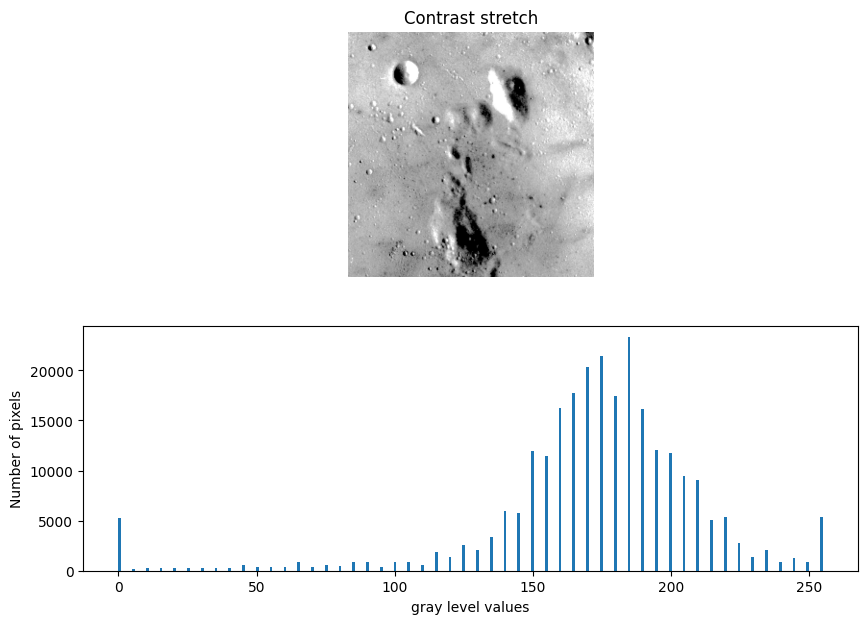

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray'); plt.axis('off'); plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values'); plt.ylabel('Number of pixels')
plt.savefig('results/task2_original.png', dpi=120)
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray'); plt.axis('off'); plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values'); plt.ylabel('Number of pixels')
plt.savefig('results/task2_contrast_stretch_2_98.png', dpi=120)
plt.show()

## Assessment
### Task 1
Using the same moon image, rescale intensity values to include all intensities within the **3rd and 80th percentiles**, and plot the histogram.

p3 = 87.0 , p80 = 118.0


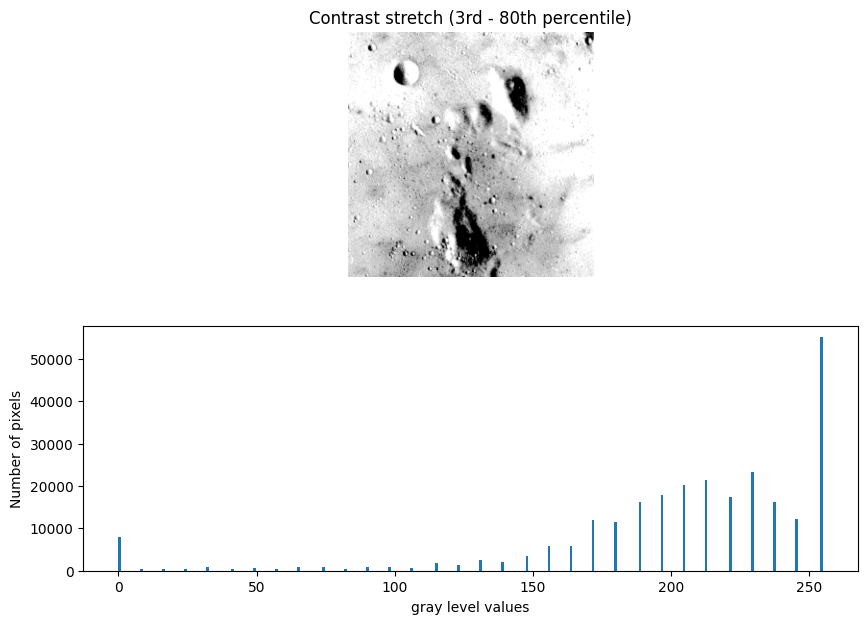

In [6]:
img = data.moon()
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print('p3 =', p3, ', p80 =', p80)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray'); plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values'); plt.ylabel('Number of pixels')
plt.savefig('results/assessment_task1_stretch_3_80.png', dpi=120)
plt.show()

**Observation:** Because the upper bound is the 80th percentile, every pixel brighter than it is clipped to 255, so a large peak appears at the white end of the histogram and the image looks brighter with more contrast in the darker/mid tones than the 2-98 version.

### Task 2
Using the moon image and `exposure.equalize_hist`, display the image and its histogram after flattening the histogram.

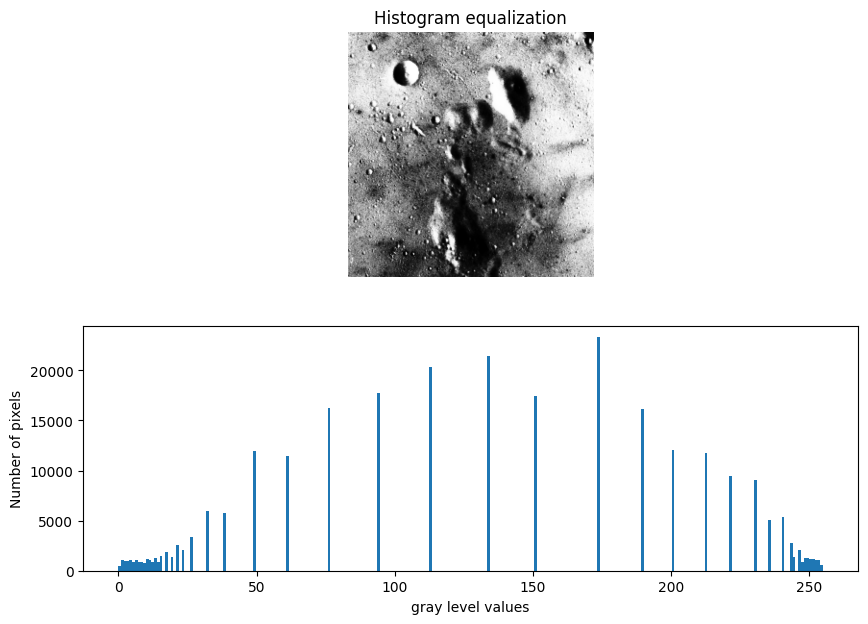

In [7]:
img = data.moon()
img_eq = exposure.equalize_hist(img)          # float image in [0, 1]
img_eq_u8 = img_as_ubyte(img_eq)              # back to 0-255 for the histogram

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray'); plt.axis('off'); plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq_u8.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values'); plt.ylabel('Number of pixels')
plt.savefig('results/assessment_task2_equalize_hist.png', dpi=120)
plt.show()

**Observation:** Equalization spreads the intensities over the whole 0-255 range, so the histogram becomes much flatter and the cumulative distribution is close to linear.

### Task 3
Use the rocket image (as reference) and the Chelsea image (from `skimage.data`) and implement histogram matching.

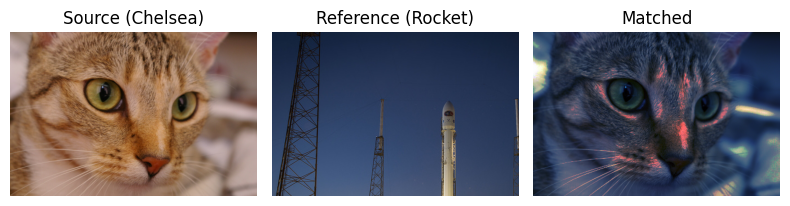

In [8]:
reference = data.rocket()
image = data.chelsea()
matched = match_histograms(image, reference, channel_axis=-1)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(8, 3), sharex=True, sharey=True)
for aa in (ax1, ax2, ax3):
    aa.set_axis_off()
ax1.imshow(image);     ax1.set_title('Source (Chelsea)')
ax2.imshow(reference); ax2.set_title('Reference (Rocket)')
ax3.imshow(matched);   ax3.set_title('Matched')
plt.tight_layout()
plt.savefig('results/assessment_task3_matched_images.png', dpi=120)
plt.show()

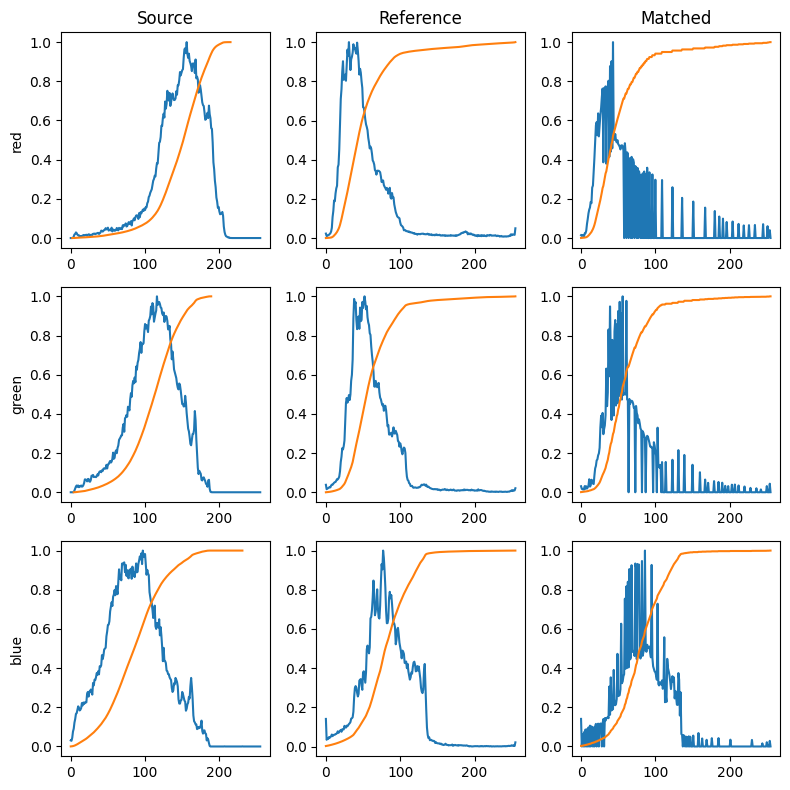

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(8, 8))
for i, img_ in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.histogram(img_[..., c], source_range='dtype')
        axes[c, i].plot(bins, img_hist / img_hist.max())
        img_cdf, bins = exposure.cumulative_distribution(img_[..., c])
        axes[c, i].plot(bins, img_cdf)
        axes[c, 0].set_ylabel(c_color)
axes[0, 0].set_title('Source')
axes[0, 1].set_title('Reference')
axes[0, 2].set_title('Matched')
plt.tight_layout()
plt.savefig('results/assessment_task3_histograms_cdf.png', dpi=120)
plt.show()

**Observation:** After matching, the cumulative distribution of each RGB channel of Chelsea follows the one of the rocket image, so the cat image takes on the rocket image's color/intensity distribution.